In [214]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


In [193]:
def extract_series(df):
    df_temp = df

    # Convert 'id' column to string type
    df_temp['id'] = df_temp['id'].astype(str)
    # Add a new column 'series' which is the first three digits of 'id'
    df_temp['series'] = df_temp['id'].str[:3].astype(int)

    # Read the series.csv file
    series = pd.read_csv('Series Name.csv')

    # Merge data with series on the 'series' column from data and 'series_id' column from series
    df_temp_1 = df_temp.merge(series, left_on='series', right_on='Series Name ID', how='left')

    cols = df_temp_1.columns.tolist()
    cols.insert(1, cols.pop(cols.index('Series Name')))
    df_temp_1 = df_temp_1[cols]
    
    df_temp_1.drop(columns=['Series Name ID', 'series'], inplace=True)

    return df_temp_1

In [194]:
def extract_contry(df):
    df_temp = df
    # Add a new column 'country' which is the fourth and fifth digits of 'id'
    df_temp['country'] = df_temp['id'].str[3:5].astype(int)

# Read the country.csv file
    country = pd.read_csv('Country Name.csv')

# Merge data_series with country on the 'country' column from data_series and 'country_id' column from country
    df_temp_1 = df_temp.merge(country, left_on='country', right_on='Country Name ID', how='left')

# Insert 'location' column into the correct position
    cols = df_temp_1.columns.tolist()
    cols.insert(2, cols.pop(cols.index('Country Name')))
    df_temp_1 = df_temp_1[cols]

# Drop unnecessary columns
    df_temp_1.drop(columns=['Country Name ID', 'country'], inplace=True)
    
    return df_temp_1

In [195]:
def extract_category(df):
    df_temp = df
    # Add a new column 'country' which is the fourth and fifth digits of 'id'
    df_temp['category'] = df_temp['id'].str[5:7].astype(int)

# Read the country.csv file
    category = pd.read_excel('category_id.xlsx')

# Rename the 'id' column in the country dataframe to 'country_id'
    category.rename(columns={'id': 'category_id'}, inplace=True)

# Merge data_series with country on the 'country' column from data_series and 'country_id' column from country
    df_temp_1 = df_temp.merge(category, left_on='category', right_on='category_id', how='left')

# Insert 'location' column into the correct position
    cols = df_temp_1.columns.tolist()
    cols.insert(3, cols.pop(cols.index('Category')))
    df_temp_1 = df_temp_1[cols]

# Drop unnecessary columns
    df_temp_1.drop(columns=['category_id', 'category'], inplace=True)

    return df_temp_1

In [196]:
prosperity = pd.read_csv('prosperity.csv')
prosperity.columns = ['year', 'prosperity']

In [197]:
data = pd.read_csv('cleaned_data.csv')
data['id'] = data['id'].astype(str)
data['id'] = data['id'].apply(lambda x: f'{int(x):013}' if pd.notnull(x) else x)
#nf_data = data[data['id'].str[5:7] != '05']
data = data.set_index('id')

In [198]:
# Create a dataframe to store the id and p-values
pvalues_df = pd.DataFrame(columns=['id', 'pvalue'])

for col in range(len(data)):

    # Ensure y and x have the same length
    x = data.iloc[col].values.reshape(-1, 1)
    y = prosperity['prosperity']

    # Add a constant to the model (intercept)
    x = sm.add_constant(x)
    model = sm.OLS(y, x).fit()

    pvalues_df.loc[col, 'id'] = data.index[col]
    
    # Check if model.pvalues has an index 1
    if len(model.pvalues) > 1:
        pvalues_df.loc[col, 'pvalue'] = model.pvalues[1]  # Extract the p-value for the predictor variable
    else:
        pvalues_df.loc[col, 'pvalue'] = 1 # Assign NaN if p-value is not available



/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_16702/481056520.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pvalues_df.loc[col, 'pvalue'] = model.pvalues[1]  # Extract the p-value for the predictor variable
/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_16702/481056520.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pvalues_df.loc[col, 'pvalue'] = model.pvalues[1]  # Extract the p-value for the predictor variable
/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_16702/481056520.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future 

In [288]:
pvalues_threshold = 0.1
data_significant = pvalues_df[pvalues_df['pvalue'] < pvalues_threshold]

In [289]:
# Convert 'pvalue' column to numeric
pvalues_df['pvalue'] = pd.to_numeric(pvalues_df['pvalue'], errors='coerce')


In [290]:
temp = data.reset_index()

# Get the top 10 rows with the smallest p-values
#nf_data_top10_pvalues = pvalues_df.nsmallest(100, 'pvalue')
#nf_data_top10_pvalues = nf_data_significant

data_significant_db = temp[temp['id'].isin(data_significant['id'])]

data_db = data_significant_db

In [291]:
data_significant_seires = extract_series(data_significant_db)
data_significant_country = extract_contry(data_significant_seires)
data_significant_category = extract_category(data_significant_country)

/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_16702/2738595283.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['id'] = df_temp['id'].astype(str)
/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_16702/2738595283.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['series'] = df_temp['id'].str[:3].astype(int)


In [292]:
data_significant_category.to_excel('pvalue_data.xlsx')

In [293]:
data_significant_category.groupby('Series Name').count()['id'].sort_values(ascending=False).to_csv('significant.csv')

In [294]:
data_db = data_db.drop('series', axis=1)

In [295]:
data_significant_db_transposed = data_db.transpose().reset_index()
data_significant_db_transposed.columns = data_significant_db_transposed.iloc[0]
data_significant_clean = data_significant_db_transposed.drop(0)

data_significant_clean.set_index('id', inplace=True)
data_significant_clean.index.name = None


In [296]:
data_significant_clean = data_significant_clean.apply(pd.to_numeric, errors='coerce')
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
data_significant_clean_standardized = pd.DataFrame(scaler.fit_transform(data_significant_clean), 
                                                   columns=data_significant_clean.columns, 
                                                   index=data_significant_clean.index)

In [302]:
# Define X and y
X = data_significant_clean_standardized
y = prosperity['prosperity']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Lasso model with a higher alpha value
lasso = Lasso(alpha=0.000001)  # Increase alpha to increase regularization strength

# Fit the model
lasso.fit(X_train, y_train)

# Predict on the test set
y_pred = lasso.predict(X_test)

# Check the number of non-zero coefficients
non_zero_coefficients = np.sum(lasso.coef_ != 0)

print(f"Number of non-zero coefficients: {non_zero_coefficients}")
print(f"Number of variables: {len(X.columns)}")

Number of non-zero coefficients: 3998
Number of variables: 9236


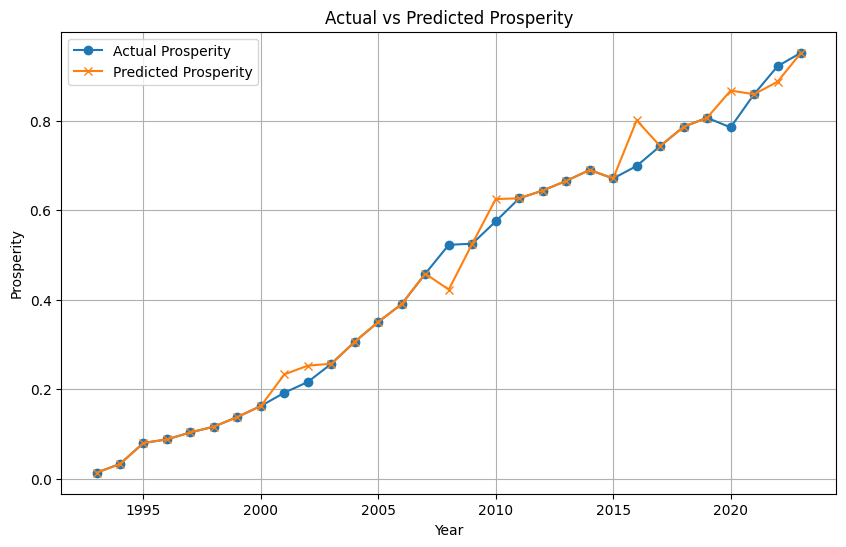

In [303]:
# Predict prosperity for the entire dataset
y_pred_all = lasso.predict(X)

# Plot the actual vs predicted prosperity
plt.figure(figsize=(10, 6))
plt.plot(prosperity['year'], prosperity['prosperity'], label='Actual Prosperity', marker='o')
plt.plot(prosperity['year'], y_pred_all, label='Predicted Prosperity', marker='x')
plt.xlabel('Year')
plt.ylabel('Prosperity')
plt.title('Actual vs Predicted Prosperity')
plt.legend()
plt.grid(True)
plt.show()

In [304]:
# Get the coefficients from the Lasso model
coefficients = lasso.coef_

# Create a DataFrame to display the coefficients with their corresponding column names
coefficients_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefficients})

# Print the DataFrame
coefficients_df.sort_values(by = 'Coefficient', ascending=False).to_csv('lasso.csv')

In [305]:
lasso_data = coefficients_df[abs(coefficients_df['Coefficient']) > 0]

temp = data.reset_index()
lasso_db = temp[temp['id'].isin(lasso_data['Feature'])]
lasso_seires = extract_series(lasso_db)
lasso_country = extract_contry(lasso_seires)
lasso_category = extract_category(lasso_country)

/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_16702/2738595283.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['id'] = df_temp['id'].astype(str)
/var/folders/qz/xwx1r5sx2k9dgf6nxmgph3200000gn/T/ipykernel_16702/2738595283.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['series'] = df_temp['id'].str[:3].astype(int)


In [306]:
lasso_category.to_excel('lasso_data.xlsx')
lasso_category.groupby('Series Name').count()['id'].sort_values(ascending=False).to_csv('lasso_series.csv')
lasso_category.groupby('Country Name').count()['id'].to_csv('lasso_country.csv')